In [1]:
# 06. 다변량 분석과 FacetGrid
# 학습 목표
# FacetGrid를 활용한 조건별 비교 분석
# Hue, Size, Style 파라미터로 차원 추가
# Tips 데이터로 팁 패턴의 복합 요인 분석
# 4-5차원 데이터를 2D 평면에 효과적으로 표현
# 1. 다변량 시각화의 필요성
# 제조업 실무 사례:

# 라인별·시프트별·제품별 품질 비교 (3개 범주 동시)
# 시간대·요일·지역별 판매량 분석
# 다양한 조건에서의 성능 테스트 결과 비교

In [2]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False
     

# Tips 데이터 로드
tips = sns.load_dataset('tips')
print(f"전체 거래: {len(tips)}건")
print(f"총 팁: ${tips['tip'].sum():.2f}")
print(f"평균 팁 비율: {(tips['tip']/tips['total_bill']).mean()*100:.1f}%")
tips.head()
     

전체 거래: 244건
총 팁: $731.58
평균 팁 비율: 16.1%


,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


In [3]:
# 2. Hue: 색상으로 그룹 구분
# 비즈니스 질문: 성별에 따라 계산서-팁 관계가 다른가?

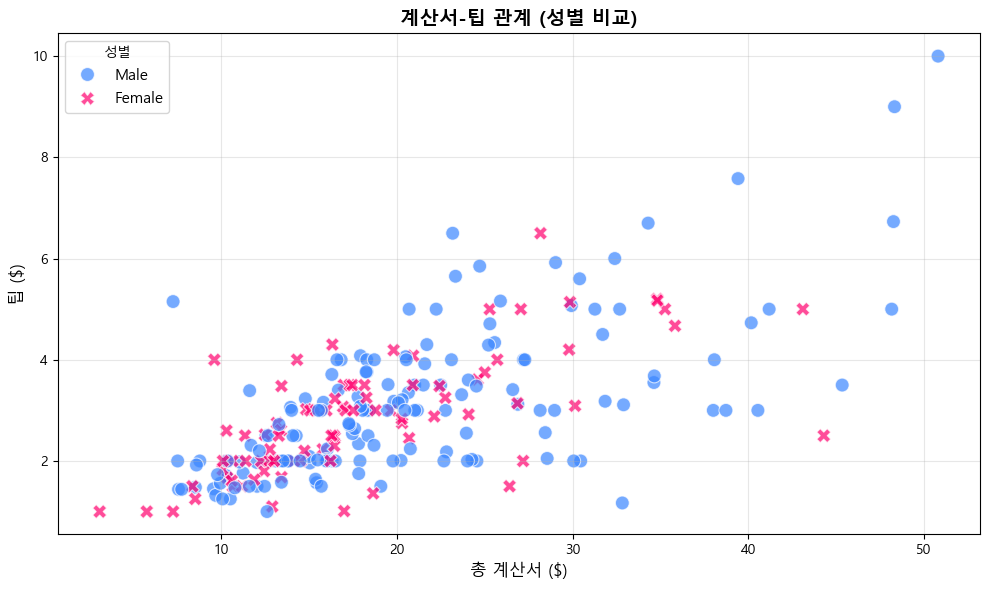


성별 팁 비율:
sex
Male      15.765055
Female    16.649074
dtype: float64


C:\Users\dlqkf\AppData\Local\Temp\ipykernel_20816\1072852843.py:19: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  print(tips.groupby('sex').apply(lambda x: (x['tip']/x['total_bill']).mean() * 100))
C:\Users\dlqkf\AppData\Local\Temp\ipykernel_20816\1072852843.py:19: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  print(tips.groupby('sex').apply(lambda x: (x['tip']/x['total_bill']).mean() * 100))


In [4]:
fig, ax = plt.subplots(figsize=(10, 6))

# Scatterplot with hue
sns.scatterplot(data=tips, x='total_bill', y='tip', hue='sex', 
                style='sex', s=100, alpha=0.7, ax=ax,
                palette={'Male': '#3A86FF', 'Female': '#FF006E'})

ax.set_xlabel('총 계산서 ($)', fontsize=12)
ax.set_ylabel('팁 ($)', fontsize=12)
ax.set_title('계산서-팁 관계 (성별 비교)', fontsize=14, fontweight='bold')
ax.legend(title='성별', fontsize=11)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# 통계 확인
print("\n성별 팁 비율:")
print(tips.groupby('sex').apply(lambda x: (x['tip']/x['total_bill']).mean() * 100))

# 💡 인사이트: 남성과 여성의 팁 패턴 유사, 차이 미미 (남성 15.8%, 여성 16.6%)

In [5]:
# 3. Size: 점 크기로 추가 변수 표현
# 비즈니스 질문: 테이블 인원수가 팁에 영향을 미치나?

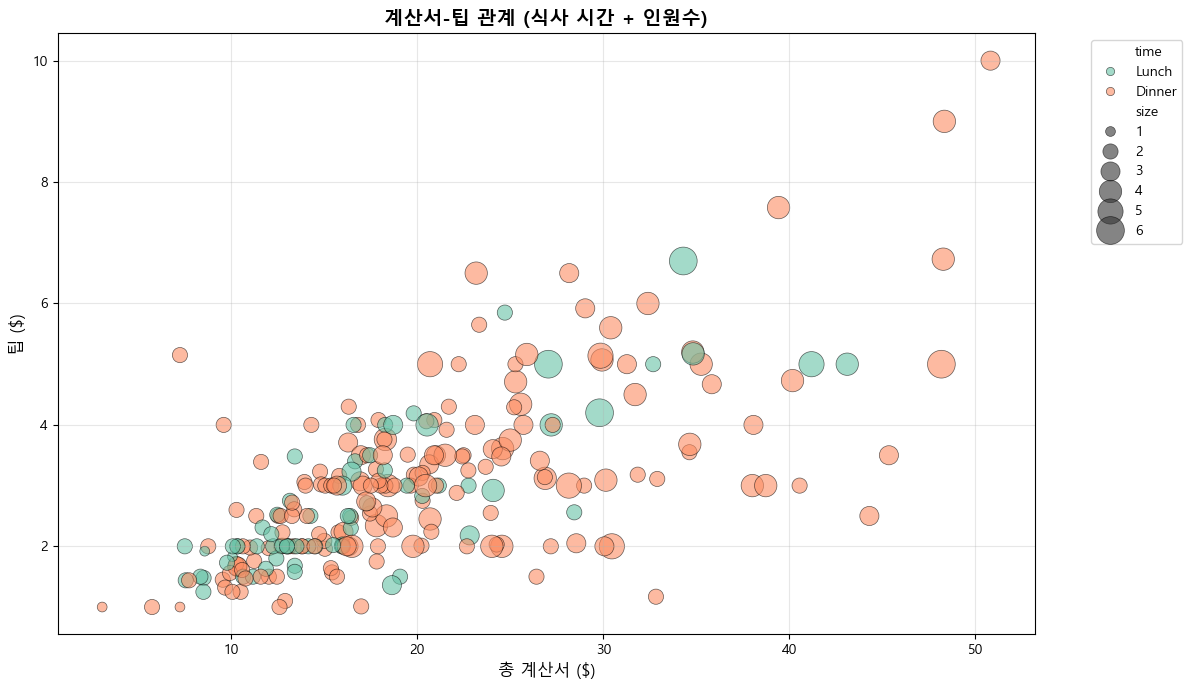

In [6]:
fig, ax = plt.subplots(figsize=(12, 7))

# Scatterplot with hue and size
sns.scatterplot(data=tips, x='total_bill', y='tip', 
                hue='time', size='size', sizes=(50, 400),
                alpha=0.6, ax=ax, palette='Set2',
                edgecolor='black', linewidth=0.5)

ax.set_xlabel('총 계산서 ($)', fontsize=12)
ax.set_ylabel('팁 ($)', fontsize=12)
ax.set_title('계산서-팁 관계 (식사 시간 + 인원수)', fontsize=14, fontweight='bold')
ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=10)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# 💡 인사이트: 큰 원(많은 인원)이 우상단 집중 → 인원 많을수록 계산서·팁 모두 증가
# 💡 Dinner(저녁)에서 고액 거래 많음

In [7]:
# 4. Style: 마커 모양으로 차원 추가
# 비즈니스 질문: 흡연 여부가 팁 패턴에 영향을 주나?

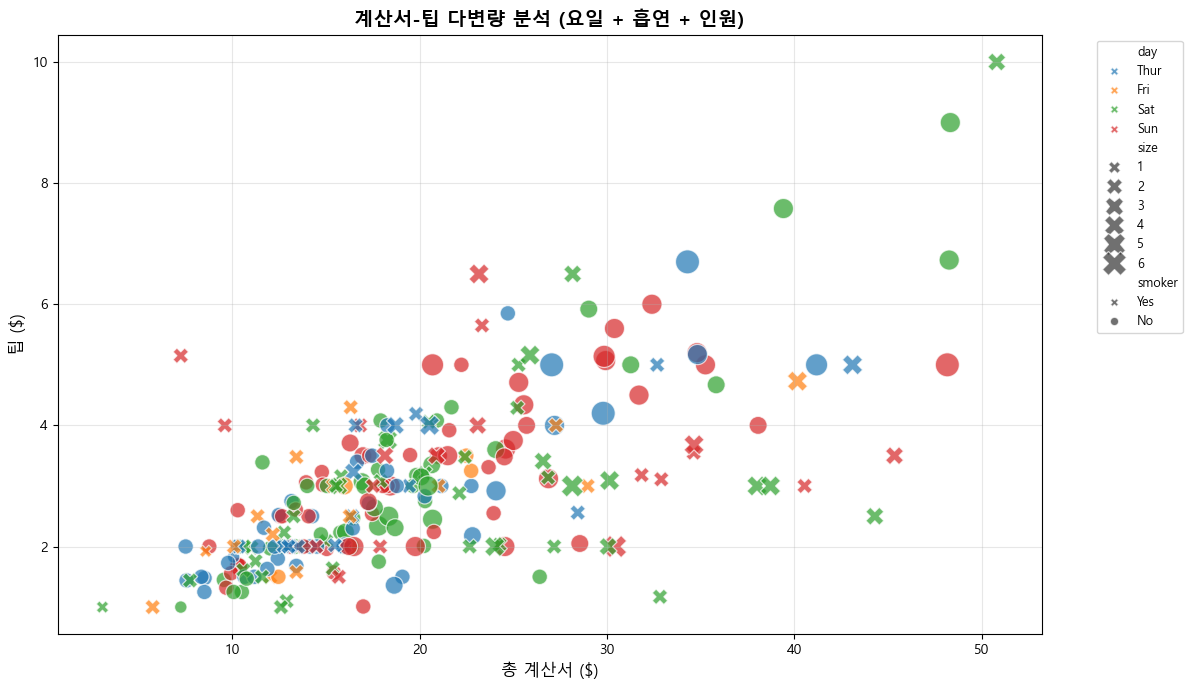

In [8]:

fig, ax = plt.subplots(figsize=(12, 7))

# Scatterplot with hue, size, and style
sns.scatterplot(data=tips, x='total_bill', y='tip',
                hue='day', style='smoker', size='size',
                sizes=(80, 300), alpha=0.7, ax=ax,
                palette='tab10', markers={'Yes': 'X', 'No': 'o'})

ax.set_xlabel('총 계산서 ($)', fontsize=12)
ax.set_ylabel('팁 ($)', fontsize=12)
ax.set_title('계산서-팁 다변량 분석 (요일 + 흡연 + 인원)', fontsize=14, fontweight='bold')
ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=9)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# 💡 인사이트: X 마커(흡연자)와 O 마커(비흡연자) 분포 유사 → 흡연 여부는 팁에 영향 적음
# 💡 주말(Sat, Sun)에 거래 집중